# SAD 2026L

## Projekt 2 (zadania 1-5)

### Karol Chądzyński

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold, ParameterGrid
from sklearn.preprocessing import StandardScaler

RANDOM_STATE: int = 42

## 1. Wstepna analiza danych

In [5]:
bike_data: pd.DataFrame = pd.read_csv("data-00-raw/bike_train.csv", index_col=0)
bike_data["date"] = pd.to_datetime(bike_data["date"])
bike_data.head()

,date,wcond,temp,atemp,hum,wind,count
1,2022-01-01,2,9.1,13.2,79.78,10.43,982
2,2022-01-02,2,9.9,12.7,68.91,16.16,797
3,2022-01-03,1,3.1,4.5,43.29,16.14,1351
4,2022-01-04,1,3.2,5.6,58.45,10.42,1559
5,2022-01-05,1,4.3,6.5,43.26,12.15,1597


### 1a. Brakujace wartosci

In [6]:
missing_value_counts: pd.Series = bike_data.isna().sum()
missing_value_counts

date     0
wcond    0
temp     0
atemp    0
hum      0
wind     0
count    0
dtype: int64

Zadna z kolumn nie zawiera wartosci brakujacych (wszystkie liczniki NaN sa rowne 0), wiec imputacja danych nie jest konieczna.

### 1b. Brak istnienia wartości `wcond = 4`

In [7]:
bike_data["wcond"].value_counts()

wcond
1    226
2    124
3     15
Name: count, dtype: int64

### 1b. Temperatura i liczba wypozyczen w czasie

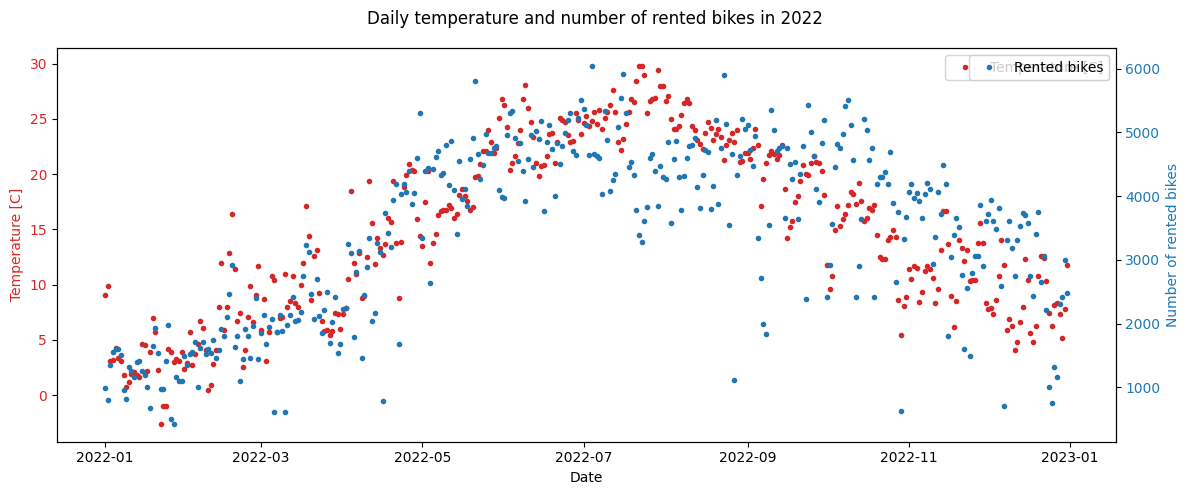

In [ ]:
def plot_temperature_and_rentals(data: pd.DataFrame) -> None:
    """Plot daily temperature and bike rental count on a shared time axis.

    :param data: DataFrame containing ``date``, ``temp`` and ``count`` columns.
    :type data: pd.DataFrame
    :return: None
    :rtype: None
    """
    fig, temperature_axis = plt.subplots(figsize=(12, 5))
    temperature_axis.plot(data["date"], data["temp"], color="tab:red", label="Temperature [C]", ls = "", marker = ".",)
    temperature_axis.set_xlabel("Date")
    temperature_axis.set_ylabel("Temperature [C]", color="tab:red")
    temperature_axis.tick_params(axis="y", labelcolor="tab:red")
    temperature_axis.legend()

    rentals_axis = temperature_axis.twinx()
    rentals_axis.plot(data["date"], data["count"], color="tab:blue", label="Rented bikes", ls = "", marker = ".")
    rentals_axis.set_ylabel("Number of rented bikes", color="tab:blue")
    rentals_axis.tick_params(axis="y", labelcolor="tab:blue")
    rentals_axis.legend()

    fig.suptitle("Daily temperature and number of rented bikes in 2022")
    fig.tight_layout()
    plt.show()


plot_temperature_and_rentals(bike_data)

### 1c. Korelacje zmiennych pogodowych

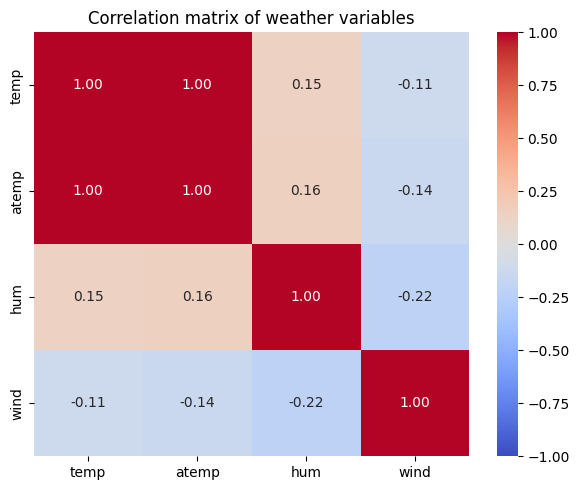

In [13]:
def plot_correlation_heatmap(data: pd.DataFrame, columns: list[str]) -> None:
    """Plot an annotated correlation heatmap for the given numeric columns.

    :param data: DataFrame containing the columns to correlate.
    :type data: pd.DataFrame
    :param columns: Names of the quantitative columns to include.
    :type columns: list[str]
    :return: None
    :rtype: None
    """
    correlation_matrix = data[columns].corr()
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
    ax.set_title("Correlation matrix of weather variables")
    fig.tight_layout()
    plt.show()


weather_quant_columns: list[str] = ["temp", "atemp", "hum", "wind"]
plot_correlation_heatmap(bike_data, weather_quant_columns)

### 1d. Zmienna weekend

In [14]:
bike_data["weekend"] = (bike_data["date"].dt.dayofweek >= 5).astype(int)
bike_data[["date", "weekend"]].head(10)

,date,weekend
1,2022-01-01,1
2,2022-01-02,1
3,2022-01-03,0
4,2022-01-04,0
5,2022-01-05,0
6,2022-01-06,0
7,2022-01-07,0
8,2022-01-08,1
9,2022-01-09,1
10,2022-01-10,0


## 2. Analiza skladowych glownych (PCA)

In [15]:
weather_scaler = StandardScaler()
weather_scaled: np.ndarray = weather_scaler.fit_transform(bike_data[weather_quant_columns])

weather_pca = PCA(random_state=RANDOM_STATE)
weather_pca.fit(weather_scaled)

explained_variance_ratio: np.ndarray = weather_pca.explained_variance_ratio_
cumulative_explained_variance: np.ndarray = np.cumsum(explained_variance_ratio)
n_components_for_90pct: int = int(np.argmax(cumulative_explained_variance >= 0.9) + 1)

pca_summary: pd.DataFrame = pd.DataFrame({
    "component": np.arange(1, len(explained_variance_ratio) + 1),
    "explained_variance_ratio": explained_variance_ratio,
    "cumulative_explained_variance": cumulative_explained_variance,
})
pca_summary

,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.521194,0.521194
1,2,0.282050,0.803244
2,3,0.195925,0.999168
3,4,0.000832,1.000000


In [16]:
print(f"Number of principal components explaining at least 90% of variance: {n_components_for_90pct}")

Number of principal components explaining at least 90% of variance: 3


## 3. Model lasow losowych (Random Forest)

### Przygotowanie macierzy cech i podzialow walidacji krzyzowej

In [17]:
wcond_dummies: pd.DataFrame = pd.get_dummies(bike_data["wcond"], prefix="wcond", drop_first=True)
feature_matrix: pd.DataFrame = pd.concat(
    [bike_data[["temp", "atemp", "hum", "wind", "weekend"]], wcond_dummies], axis=1
)
target: pd.Series = bike_data["count"]

N_FOLDS: int = 5
kfold_splitter = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_fold_indices: list[tuple[np.ndarray, np.ndarray]] = list(kfold_splitter.split(feature_matrix))

feature_matrix.head()

,temp,atemp,hum,wind,weekend,wcond_2,wcond_3
1,9.1,13.2,79.78,10.43,1,True,False
2,9.9,12.7,68.91,16.16,1,True,False
3,3.1,4.5,43.29,16.14,0,False,False
4,3.2,5.6,58.45,10.42,0,False,False
5,4.3,6.5,43.26,12.15,0,False,False


### 3a. Przeszukiwanie siatki hiperparametrow

In [18]:
def evaluate_random_forest_cv(
    feature_matrix: pd.DataFrame,
    target: pd.Series,
    fold_indices: list[tuple[np.ndarray, np.ndarray]],
    hyperparameters: dict[str, int],
    random_state: int,
) -> tuple[float, float]:
    """Evaluate a Random Forest regressor using precomputed cross-validation folds.

    :param feature_matrix: Feature matrix used for training and validation.
    :type feature_matrix: pd.DataFrame
    :param target: Target variable values.
    :type target: pd.Series
    :param fold_indices: List of (train_index, validation_index) pairs.
    :type fold_indices: list[tuple[np.ndarray, np.ndarray]]
    :param hyperparameters: Hyperparameters passed to ``RandomForestRegressor``.
    :type hyperparameters: dict[str, int]
    :param random_state: Random seed used for the model.
    :type random_state: int
    :return: Tuple of (mean training MSE, mean validation MSE) across folds.
    :rtype: tuple[float, float]
    """
    train_mse_values: list[float] = []
    val_mse_values: list[float] = []
    for train_idx, val_idx in fold_indices:
        X_train, X_val = feature_matrix.iloc[train_idx], feature_matrix.iloc[val_idx]
        y_train, y_val = target.iloc[train_idx], target.iloc[val_idx]

        model = RandomForestRegressor(random_state=random_state, **hyperparameters)
        model.fit(X_train, y_train)

        train_mse_values.append(mean_squared_error(y_train, model.predict(X_train)))
        val_mse_values.append(mean_squared_error(y_val, model.predict(X_val)))

    return float(np.mean(train_mse_values)), float(np.mean(val_mse_values))

In [19]:
random_forest_param_grid: dict[str, list[int]] = {
    "n_estimators": [50, 100, 150, 200, 250],
    "max_depth": [3, 5, 7, 10, 15],
    "min_samples_leaf": [1, 2, 4, 8, 16],
}

random_forest_configurations: list[dict[str, int]] = list(ParameterGrid(random_forest_param_grid))
print(f"Number of configurations: {len(random_forest_configurations)}")

random_forest_results: list[dict[str, float]] = []
for hyperparameters in random_forest_configurations:
    train_mse, val_mse = evaluate_random_forest_cv(
        feature_matrix, target, cv_fold_indices, hyperparameters, RANDOM_STATE
    )
    random_forest_results.append({**hyperparameters, "train_mse": train_mse, "val_mse": val_mse})

random_forest_results_df: pd.DataFrame = pd.DataFrame(random_forest_results)
random_forest_results_df.head()

Number of configurations: 125


,max_depth,min_samples_leaf,n_estimators,train_mse,val_mse
0,3,1,50,392547.839595,551774.331348
1,3,1,100,392698.980339,554163.566705
2,3,1,150,392445.982865,560084.243533
3,3,1,200,391782.472978,556692.386239
4,3,1,250,391165.744027,558635.578973


In [20]:
best_random_forest_row: pd.Series = random_forest_results_df.loc[random_forest_results_df["val_mse"].idxmin()]
best_random_forest_params: dict[str, int] = {
    key: int(best_random_forest_row[key]) for key in random_forest_param_grid
}
best_random_forest_train_mse: float = float(best_random_forest_row["train_mse"])
best_random_forest_val_mse: float = float(best_random_forest_row["val_mse"])

print(f"Best hyperparameters: {best_random_forest_params}")
print(f"Training MSE: {best_random_forest_train_mse:.2f}")
print(f"Validation MSE: {best_random_forest_val_mse:.2f}")

Best hyperparameters: {'n_estimators': 200, 'max_depth': 7, 'min_samples_leaf': 1}
Training MSE: 131759.42
Validation MSE: 476015.10


### 3b. Wykres bledu treningowego vs walidacyjnego

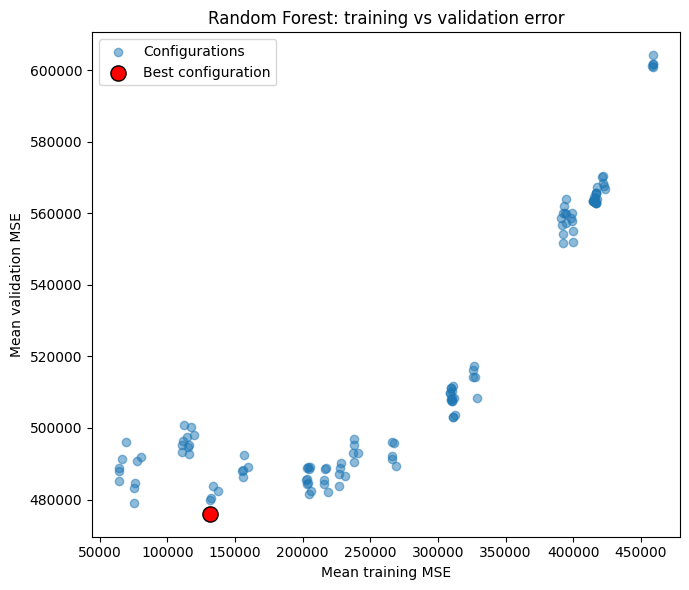

In [21]:
def plot_train_vs_val_error(results_df: pd.DataFrame, best_row: pd.Series) -> None:
    """Plot training vs validation MSE for every hyperparameter configuration.

    :param results_df: DataFrame with ``train_mse`` and ``val_mse`` columns for every configuration.
    :type results_df: pd.DataFrame
    :param best_row: Row of ``results_df`` corresponding to the configuration with the lowest validation MSE.
    :type best_row: pd.Series
    :return: None
    :rtype: None
    """
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(results_df["train_mse"], results_df["val_mse"], alpha=0.5, label="Configurations")
    ax.scatter(
        best_row["train_mse"], best_row["val_mse"],
        color="red", s=120, edgecolor="black", zorder=5, label="Best configuration",
    )
    ax.set_xlabel("Mean training MSE")
    ax.set_ylabel("Mean validation MSE")
    ax.set_title("Random Forest: training vs validation error")
    ax.legend()
    fig.tight_layout()
    plt.show()


plot_train_vs_val_error(random_forest_results_df, best_random_forest_row)

## 4. Regresja grzbietowa (Ridge)

### 4a. Siatka wartosci lambda i walidacja krzyzowa

In [22]:
def evaluate_ridge_cv(
    feature_matrix: pd.DataFrame,
    target: pd.Series,
    fold_indices: list[tuple[np.ndarray, np.ndarray]],
    alpha: float,
) -> tuple[list[float], list[float]]:
    """Evaluate Ridge regression using precomputed cross-validation folds.

    Features are standardized separately within each fold to avoid data leakage.

    :param feature_matrix: Feature matrix used for training and validation.
    :type feature_matrix: pd.DataFrame
    :param target: Target variable values.
    :type target: pd.Series
    :param fold_indices: List of (train_index, validation_index) pairs.
    :type fold_indices: list[tuple[np.ndarray, np.ndarray]]
    :param alpha: Regularization strength (lambda) of the Ridge model.
    :type alpha: float
    :return: Tuple of (training MSE per fold, validation MSE per fold).
    :rtype: tuple[list[float], list[float]]
    """
    train_mse_values: list[float] = []
    val_mse_values: list[float] = []
    for train_idx, val_idx in fold_indices:
        X_train, X_val = feature_matrix.iloc[train_idx], feature_matrix.iloc[val_idx]
        y_train, y_val = target.iloc[train_idx], target.iloc[val_idx]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)

        model = Ridge(alpha=alpha)
        model.fit(X_train_scaled, y_train)

        train_mse_values.append(mean_squared_error(y_train, model.predict(X_train_scaled)))
        val_mse_values.append(mean_squared_error(y_val, model.predict(X_val_scaled)))

    return train_mse_values, val_mse_values

In [23]:
lambda_grid: np.ndarray = np.logspace(-3, 3, 10)

ridge_fold_results: list[dict[str, object]] = []
for alpha in lambda_grid:
    train_mses, val_mses = evaluate_ridge_cv(feature_matrix, target, cv_fold_indices, alpha)
    ridge_fold_results.append({
        "alpha": alpha,
        "train_mses": train_mses,
        "val_mses": val_mses,
        "cv_mse": float(np.mean(val_mses)),
    })

ridge_results_df: pd.DataFrame = pd.DataFrame(ridge_fold_results)
ridge_results_df[["alpha", "cv_mse"]]

,alpha,cv_mse
0,0.001000,6.194336e+05
1,0.004642,6.193848e+05
2,0.021544,6.191641e+05
3,0.100000,6.182458e+05
4,0.464159,6.154537e+05
5,2.154435,6.114234e+05
6,10.000000,6.091976e+05
7,46.415888,6.144743e+05
8,215.443469,7.053039e+05
9,1000.000000,1.134892e+06


### 4b. Wykres bledow w zaleznosci od lambda

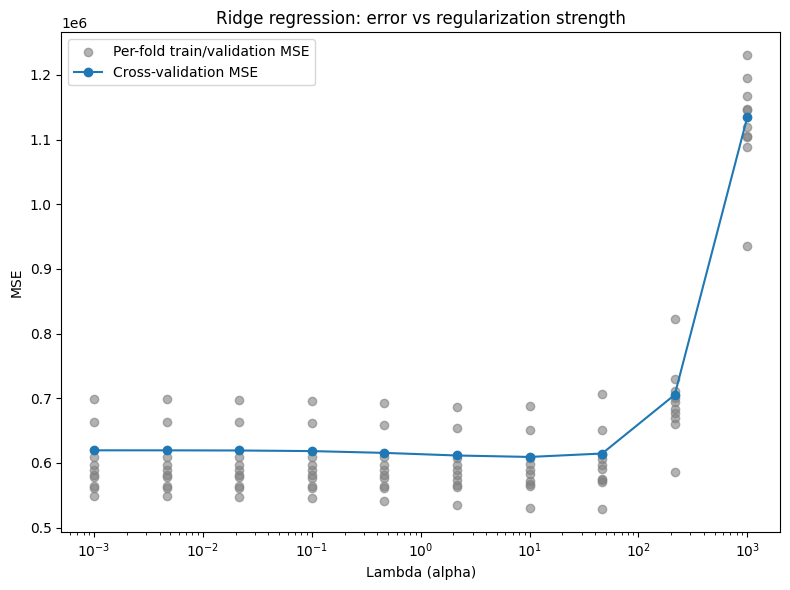

In [24]:
def plot_ridge_errors(results_df: pd.DataFrame) -> None:
    """Plot per-fold training/validation MSE and the cross-validation MSE against lambda.

    For every value of lambda, 10 points are plotted (5 training and 5 validation MSE values,
    one per cross-validation fold), together with the mean cross-validation MSE highlighted
    in a different color.

    :param results_df: DataFrame with ``alpha``, ``train_mses``, ``val_mses`` and ``cv_mse`` columns.
    :type results_df: pd.DataFrame
    :return: None
    :rtype: None
    """
    fig, ax = plt.subplots(figsize=(8, 6))
    for row_index, row in enumerate(results_df.itertuples(index=False)):
        fold_errors = np.concatenate([row.train_mses, row.val_mses])
        alphas_repeated = np.full(fold_errors.shape, row.alpha)
        ax.scatter(
            alphas_repeated, fold_errors, color="gray", alpha=0.6,
            label="Per-fold train/validation MSE" if row_index == 0 else None,
        )

    ax.plot(
        results_df["alpha"], results_df["cv_mse"],
        color="tab:blue", marker="o", label="Cross-validation MSE",
    )

    ax.set_xscale("log")
    ax.set_xlabel("Lambda (alpha)")
    ax.set_ylabel("MSE")
    ax.set_title("Ridge regression: error vs regularization strength")
    ax.legend()
    fig.tight_layout()
    plt.show()


plot_ridge_errors(ridge_results_df)

### 4c. Najlepsza wartosc lambda i porownanie z lasami losowymi

In [25]:
best_ridge_row: pd.Series = ridge_results_df.loc[ridge_results_df["cv_mse"].idxmin()]
best_ridge_alpha: float = float(best_ridge_row["alpha"])
best_ridge_val_mse: float = float(best_ridge_row["cv_mse"])

print(f"Best lambda: {best_ridge_alpha:.4f}")
print(f"Ridge regression validation MSE: {best_ridge_val_mse:.2f}")
print(f"Random Forest validation MSE: {best_random_forest_val_mse:.2f}")

Best lambda: 10.0000
Ridge regression validation MSE: 609197.57
Random Forest validation MSE: 476015.10


## 5. Podsumowanie tabelaryczne

In [26]:
def evaluate_mean_baseline_cv(
    target: pd.Series,
    fold_indices: list[tuple[np.ndarray, np.ndarray]],
) -> list[float]:
    """Evaluate a baseline model predicting the training-fold mean for every validation sample.

    :param target: Target variable values.
    :type target: pd.Series
    :param fold_indices: List of (train_index, validation_index) pairs.
    :type fold_indices: list[tuple[np.ndarray, np.ndarray]]
    :return: Validation MSE for each fold.
    :rtype: list[float]
    """
    val_mse_values: list[float] = []
    for train_idx, val_idx in fold_indices:
        y_train, y_val = target.iloc[train_idx], target.iloc[val_idx]
        prediction = np.full(shape=len(val_idx), fill_value=y_train.mean())
        val_mse_values.append(mean_squared_error(y_val, prediction))

    return val_mse_values


reference_val_mses: list[float] = evaluate_mean_baseline_cv(target, cv_fold_indices)

summary_table: pd.DataFrame = pd.DataFrame({
    "model": ["Random Forest (best)", "Ridge regression (best)", "Reference (mean predictor)"],
    "cv_mse": [
        best_random_forest_val_mse,
        best_ridge_val_mse,
        float(np.mean(reference_val_mses)),
    ],
})
summary_table["cv_rmse"] = np.sqrt(summary_table["cv_mse"])
summary_table

,model,cv_mse,cv_rmse
0,Random Forest (best),4.760151e+05,689.938478
1,Ridge regression (best),6.091976e+05,780.511095
2,Reference (mean predictor),1.910869e+06,1382.341997
